[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HisameOgasahara/paper_implementation/blob/main/mean_flow_experiment1.ipynb)

# mean_flow_experiment1 — 하나의 MeanFlow로 여러 분석 논문 진단 재현

**목적.** `flow_basic.ipynb`의 FashionMNIST + 소형 DiT + MeanFlow를 기준 모델 하나로 두고,
서로 다른 분석 논문이 실제로 계산한 **동역학/기하/표현/일반화 진단량**을 단계적으로 적용한다.

이 노트북의 원칙:

- 논문에서 직접 계산한 양과, 이 노트북에서 편의를 위해 추가한 양을 구분한다.
- 원 논문의 절대 수치 재현을 주장하지 않는다. 데이터셋, 해상도, backbone, noise schedule이 다르기 때문이다.
- 각 실습 직전 Markdown에 **논문 질문 → 원문 근거 → 원 논문 Figure/Algorithm → 여기서 유지하는 양 → adaptation**을 적는다.
- score/denoiser가 필요한 논문은 MeanFlow의 diagonal slice \(u_\theta(z,t,t)\)에서 instantaneous velocity를 얻고,
  현재 linear Gaussian path에 대한 정확한 대수 관계를 이용한다.
- 모든 분석은 T4에서 실행 가능한 규모로 줄였지만, 관찰하는 **수학량 자체**는 가능한 한 원 논문과 동일하게 유지한다.

### 기준 모델
- Mean Flows for One-step Generative Modeling, NeurIPS 2025 Oral  
  https://arxiv.org/abs/2505.13447

### 진단 논문
1. Stanczuk et al., **Diffusion Models Encode the Intrinsic Dimension of Data Manifolds**, ICML 2024  
   https://proceedings.mlr.press/v235/stanczuk24a.html
2. Ventura et al., **Manifolds, Random Matrices and Spectral Gaps**, ICLR 2025  
   https://arxiv.org/abs/2410.05898
3. Niedoba et al., **Towards a Mechanistic Explanation of Diffusion Model Generalization**, ICML 2025  
   https://proceedings.mlr.press/v267/niedoba25a.html
4. Li et al., **Understanding Representation Dynamics of Diffusion Models via Low-Dimensional Modeling**, NeurIPS 2025  
   https://proceedings.neurips.cc/paper_files/paper/2025/hash/9a3b1949b6da9b8facfdc28e1b4722ed-Abstract-Conference.html
5. Qian et al., **Boosting Diffusion Models with Moving Average Sampling in Frequency Domain**, CVPR 2024  
   https://openaccess.thecvf.com/content/CVPR2024/html/Qian_Boosting_Diffusion_Models_with_Moving_Average_Sampling_in_Frequency_Domain_CVPR_2024_paper.html
6. Buchanan et al., **On the Edge of Memorization in Diffusion Models**, NeurIPS 2025  
   https://papers.nips.cc/paper_files/paper/2025/hash/8a6a3f289e3e2654509ccfdd631e592e-Abstract-Conference.html
7. **AlphaFlow: Understanding and Improving MeanFlow Models**, ICLR 2026  
   https://arxiv.org/abs/2510.20771

> **2026-09-09 기준 모델 수정.** 기존 Stanczuk/Ventura/Niedoba/Li/Qian/Buchanan/AlphaFlow 진단 섹션은 유지하고, 기준 MeanFlow 학습부만 conditional DiT + separate t/h embedding + adaLN-Zero + logit-normal time sampling + adaptive loss normalization으로 교체했다.


## 0-1. 설치 · 재현성 · T4용 분석 budget

이 셀은 실험 공통 환경만 준비한다. 표준 데이터셋은 Colab에서 빠르게 받을 수 있도록 Hugging Face 경로를 우선 사용하고,
실패 시 명시적인 fallback을 둔다.

분석 budget은 **원 논문의 sample count를 재현하는 값이 아니다.**
예를 들어 Niedoba et al.은 Figure 2에서 각 \(t\)마다 10,000 forward samples를 사용하지만,
여기서는 동일한 MSE를 작은 표본으로 계산한다.

Colab에서 필요한 패키지만 설치한다.

seed, device, TF32, checkpoint 경로만 설정한다.

학습 budget과 MeanFlow sampler/loss hyperparameter를 한 곳에 둔다.


In [1]:
!pip -q install datasets pandas scipy scikit-learn PyWavelets


In [2]:
# Standard-library imports
import copy
import math
import os
import random
import time
import warnings

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pywt
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from torch.func import jvp
from torch.nn.attention import SDPBackend, sdpa_kernel
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid

# Reproducibility and runtime configuration
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cuda.matmul.allow_tf32 = True
# torch.func.jvp uses forward-mode AD. The native MultiheadAttention
# fast path does not support it, so use the regular differentiable path.
torch.backends.mha.set_fastpath_enabled(False)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
AMP = DEVICE == "cuda"
CHECKPOINT_DIR = "/content/mean_flow_experiment1_ckpts"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("device:", DEVICE)
if DEVICE == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))

# Training hyperparameters
TRAIN_STEPS = 20_000
BATCH_SIZE = 128
LEARNING_RATE = 0.0003
WEIGHT_DECAY = 0.0001
EMA_DECAY = 0.999
SNAPSHOT_EVERY = 1000
P_MEAN = -0.4
P_STD = 1.0
DATA_PROPORTION = 0.75
NORM_EPS = 0.01
NUM_CLASSES = 10
NULL_CLASS = NUM_CLASSES
LABEL_DROPOUT = 0.10

# Early stopping keeps 20k as a safety cap but avoids unnecessary training.
EARLY_STOP_MIN_STEPS = 5_000
EARLY_STOP_CHECK_EVERY = 1_000
EARLY_STOP_PATIENCE = 2
EARLY_STOP_MIN_RELATIVE_IMPROVEMENT = 0.005
EARLY_STOP_VALIDATION_BATCHES = 8


device: cuda
gpu: Tesla T4


## 0-2. FashionMNIST

`flow_basic.ipynb`와 같은 데이터 공간을 유지한다.

\[
X=\mathbb{R}^{1\times 28\times 28}
\]

이며 pixel은 \([0,1]\)에서 \([-1,1]\)로 선형 변환한다. 라벨은 **MeanFlow 생성학습의 class condition**으로 사용한다. 분석 단계에서는 같은 라벨을 그대로 전달하며,
라벨이 없는 기존 진단 호출은 classifier-free null condition으로 동작하도록 호환 경로를 둔다.


In [3]:
# Load FashionMNIST, with an explicit fallback mirror
try:
    dataset = load_dataset("zalando-datasets/fashion_mnist")
except Exception:
    dataset = load_dataset("anonyme449/fashion_mnist")
to_tensor = ToTensor()

# Convert images to [-1, 1] and pack class labels

def collate_fashion_mnist(batch):
    images = torch.stack([to_tensor(item["image"]) for item in batch])
    images = images * 2.0 - 1.0
    labels = torch.tensor(
        [item["label"] for item in batch],
        dtype=torch.long,
    )
    return images, labels

# Build training and test data loaders
train_loader = DataLoader(
    dataset["train"],
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True,
    collate_fn=collate_fashion_mnist,
)

test_loader = DataLoader(
    dataset["test"],
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    collate_fn=collate_fashion_mnist,
)

# Quick shape and value-range sanity check
sample_images, sample_labels = next(iter(train_loader))
print(
    sample_images.shape,
    sample_images.min().item(),
    sample_images.max().item(),
)

print(sample_labels.shape)


README.md:   0%|          | 0.00/9.02k [00:00<?, ?B/s]

fashion_mnist/train-00000-of-00001.parqu(…): reconstructing file:   0%|          |  0.00B / 30.9MB            

fashion_mnist/train-00000-of-00001.parqu(…): downloading bytes:           |  0.00B            

fashion_mnist/test-00000-of-00001.parque(…): reconstructing file:   0%|          |  0.00B / 5.18MB            

fashion_mnist/test-00000-of-00001.parque(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

torch.Size([128, 1, 28, 28]) -1.0 1.0
torch.Size([128])


## 0-3. Conditional TinyDiT — 공식 MeanFlow/DiT 설정에 맞춘 기준 backbone

기존 `dim=96, depth=3` 및 공통 scalar embedding 대신 다음을 사용한다.

- patch size \(4\), \(7	imes7=49\) tokens
- hidden dimension \(224\), depth \(4\), attention heads \(8\)
- 시간은 \(t\)와 interval \(h=t-r\)를 별도 embedding
- FashionMNIST class \(y\in\{0,\dots,9\}\)를 class embedding으로 조건화
- 기존 분석 호출과 호환하기 위한 null class 추가
- 각 DiT block modulation과 final modulation/output을 zero initialization (adaLN-Zero)

`forward_features`는 뒤의 representation 분석을 위해 유지한다. JVP는 forward-mode AD를 사용하므로 setup에서 PyTorch native MHA fast path를 끄고, attention weight는 사용하지 않아 `need_weights=False`로 둔다.

현재 시간 \(t\)와 interval \(h=t-r\)를 각각 임베딩할 때 사용하는 공통 Fourier/MLP 모듈이다.

각 Transformer block의 attention/MLP와 conditioning modulation을 정의한다. modulation 마지막 선형층은 zero initialization으로 시작한다.

입력 patch embedding, positional embedding, \(t\)/\(h\)/class conditioning, final adaLN modulation과 image projection을 한 곳에 정의한다.


In [4]:
# Embed scalar time variables with Fourier features and an MLP

class ScalarEmbed(nn.Module):
    def __init__(self, dim=224, fourier=128):
        super().__init__()
        self.fourier = fourier
        self.mlp = nn.Sequential(
            nn.Linear(fourier, dim),
            nn.SiLU(),
            nn.Linear(dim, dim),
        )

    def forward(self, scalar):
        scalar = scalar.reshape(-1, 1)
        half = self.fourier // 2
        frequencies = torch.exp(
            -math.log(10000.0)
            * torch.arange(half, device=scalar.device, dtype=scalar.dtype)
            / half
        )
        phase = scalar * frequencies[None] * 2.0 * math.pi
        embedding = torch.cat([phase.cos(), phase.sin()], dim=1)
        return self.mlp(embedding)

# Transformer block with adaLN-Zero conditioning

class DiTBlock(nn.Module):
    def __init__(self, dim=224, heads=8):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.attention = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.norm2 = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.feed_forward = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.GELU(approximate="tanh"),
            nn.Linear(4 * dim, dim),
        )
        self.modulation = nn.Sequential(nn.SiLU(), nn.Linear(dim, 6 * dim))
        nn.init.zeros_(self.modulation[-1].weight)
        nn.init.zeros_(self.modulation[-1].bias)

    def forward(self, tokens, conditioning):
        shift1, scale1, gate1, shift2, scale2, gate2 = self.modulation(
            conditioning
        ).chunk(6, dim=-1)
        hidden = self.norm1(tokens)
        hidden = hidden * (1.0 + scale1[:, None]) + shift1[:, None]
        attended, _ = self.attention(
            hidden,
            hidden,
            hidden,
            need_weights=False,
        )
        tokens = tokens + gate1[:, None] * attended
        hidden = self.norm2(tokens)
        hidden = hidden * (1.0 + scale2[:, None]) + shift2[:, None]
        tokens = tokens + gate2[:, None] * self.feed_forward(hidden)
        return tokens

# Conditional TinyDiT backbone

class TinyDiT(nn.Module):
    def __init__(self, dim=224, depth=4, heads=8, patch=4):
        super().__init__()
        self.patch = patch
        self.dim = dim
        self.input_projection = nn.Conv2d(1, dim, kernel_size=patch, stride=patch)
        self.position = nn.Parameter(torch.zeros(1, 49, dim))
        self.t_embedding = ScalarEmbed(dim)
        self.h_embedding = ScalarEmbed(dim)
        self.class_embedding = nn.Embedding(NUM_CLASSES + 1, dim)
        self.blocks = nn.ModuleList([DiTBlock(dim, heads) for _ in range(depth)])
        self.final_norm = nn.LayerNorm(dim, elementwise_affine=False, eps=1e-6)
        self.final_modulation = nn.Sequential(nn.SiLU(), nn.Linear(dim, 2 * dim))
        self.output_projection = nn.Linear(dim, patch * patch)
        nn.init.normal_(self.position, std=0.02)
        nn.init.normal_(self.class_embedding.weight, std=0.02)
        nn.init.zeros_(self.final_modulation[-1].weight)
        nn.init.zeros_(self.final_modulation[-1].bias)
        nn.init.zeros_(self.output_projection.weight)
        nn.init.zeros_(self.output_projection.bias)

    def _labels(self, batch_size, device, labels):
        if labels is None:
            return torch.full(
                (batch_size,), NULL_CLASS, device=device, dtype=torch.long
            )
        return labels.to(device=device, dtype=torch.long)

    def _conditioning(self, r, t, labels):
        h = t - r
        labels = self._labels(t.shape[0], t.device, labels)
        return self.t_embedding(t) + self.h_embedding(h) + self.class_embedding(labels)

    def _tokens(self, images):
        tokens = self.input_projection(images)
        tokens = tokens.flatten(2).transpose(1, 2)
        return tokens + self.position

    def forward_features(self, images, r, t, labels=None):
        tokens = self._tokens(images)
        conditioning = self._conditioning(r, t, labels)
        pooled_features = []
        for block in self.blocks:
            tokens = block(tokens, conditioning)
            pooled_features.append(tokens.mean(dim=1))
        return pooled_features

    def forward(self, images, r, t, labels=None):
        tokens = self._tokens(images)
        conditioning = self._conditioning(r, t, labels)
        for block in self.blocks:
            tokens = block(tokens, conditioning)
        shift, scale = self.final_modulation(conditioning).chunk(2, dim=-1)
        tokens = self.final_norm(tokens)
        tokens = tokens * (1.0 + scale[:, None]) + shift[:, None]
        patches = self.output_projection(tokens)
        patches = patches.view(images.size(0), 7, 7, self.patch, self.patch)
        images_out = patches.permute(0, 1, 3, 2, 4)
        return images_out.reshape(images.size(0), 1, 28, 28)

# Construct a fresh model on the active device

def fresh_model():
    return TinyDiT().to(DEVICE)

parameter_count = sum(parameter.numel() for parameter in fresh_model().parameters())
print("parameters:", parameter_count)


parameters: 3906352


## 0-4. MeanFlow objective — 공식 설정을 소형 FashionMNIST에 맞게 복구

MeanFlow identity와 linear Gaussian path 자체는 기존 노트북과 동일하게 유지한다.

\[
u(z_t,r,t)=v(z_t,t)-(t-r)rac{d}{dt}u(z_t,r,t)
\]

JVP tangent도 기존대로 \((v,0,1)\)이다.

이번 수정에서 바뀌는 학습 설정은 다음과 같다.

- \(t,r\) 후보를 `LogitNormal(-0.4, 1.0)`에서 뽑아 정렬
- batch의 75%는 \(r=t\) diagonal sample, 25%는 interval sample
- raw SSE 대신 `NORM_EPS=0.01` adaptive normalization
- FashionMNIST label을 class condition으로 전달
- 10% label dropout으로 null condition도 함께 학습해 기존 label-less 진단 호출과 호환

`LogitNormal(-0.4, 1.0)`에서 두 시간을 뽑아 정렬하고, batch의 75%를 diagonal \(r=t\) sample로 만든다.

학습 중 일부 label을 null class로 바꿔 기존 label-less 진단 호출과도 호환되게 한다.

JVP로 total derivative를 계산하고 stop-gradient target을 만든다.

각 sample의 raw SSE에 adaptive normalization을 적용한다. raw SSE와 interval/diagonal 비율은 별도로 기록한다.


In [5]:
# Sample scalar times from the logit-normal schedule

def logit_normal_times(batch_size, device):
    normal = torch.randn(batch_size, device=device) * P_STD + P_MEAN
    return torch.sigmoid(normal)

# Build ordered (r, t) pairs and inject diagonal r=t cases

def sample_meanflow_times(batch_size, device):
    first = logit_normal_times(batch_size, device)
    second = logit_normal_times(batch_size, device)
    t = torch.maximum(first, second)
    r = torch.minimum(first, second)
    diagonal_count = int(batch_size * DATA_PROPORTION)
    if diagonal_count > 0:
        indices = torch.randperm(batch_size, device=device)[:diagonal_count]
        r = r.clone()
        r[indices] = t[indices]
    return r, t

# Linear Gaussian interpolation path

def linear_path(clean_images, noise, t):
    scale = t[:, None, None, None]
    return (1.0 - scale) * clean_images + scale * noise

def conditional_velocity(clean_images, noise):
    return noise - clean_images

# Classifier-free label dropout

def maybe_drop_labels(labels):
    if labels is None:
        return None
    labels = labels.clone()
    drop_mask = torch.rand(labels.shape[0], device=labels.device) < LABEL_DROPOUT
    labels[drop_mask] = NULL_CLASS
    return labels

# Use the math attention backend only while forward-mode AD is active.

def meanflow_jvp(function, primals, tangents):
    with sdpa_kernel(SDPBackend.MATH):
        return jvp(function, primals, tangents)

# MeanFlow prediction and JVP target construction

def meanflow_outputs(model, clean_images, labels=None):
    # Sample once before splitting to preserve the training distribution.
    batch_size = clean_images.size(0)
    r, t = sample_meanflow_times(batch_size, clean_images.device)
    noise = torch.randn_like(clean_images)
    z_t = linear_path(clean_images, noise, t)
    velocity = conditional_velocity(clean_images, noise)
    labels_for_model = maybe_drop_labels(labels)

    diagonal_indices = torch.where(r == t)[0]
    interval_indices = torch.where(r != t)[0]
    prediction_parts = []
    target_parts = []
    index_parts = []

    # At r=t the derivative coefficient is zero; ordinary AD is sufficient.
    if diagonal_indices.numel() > 0:
        diagonal_labels = (
            None if labels_for_model is None else labels_for_model[diagonal_indices]
        )
        prediction_parts.append(model(
            z_t[diagonal_indices], r[diagonal_indices], t[diagonal_indices],
            diagonal_labels,
        ))
        target_parts.append(velocity[diagonal_indices])
        index_parts.append(diagonal_indices)

    # Compute both prediction and JVP together only for nonzero intervals.
    if interval_indices.numel() > 0:
        interval_labels = (
            None if labels_for_model is None else labels_for_model[interval_indices]
        )
        interval_t = t[interval_indices]
        interval_r = r[interval_indices]
        interval_velocity = velocity[interval_indices]

        def model_function(z_value, t_value, r_value):
            return model(z_value, r_value, t_value, interval_labels)

        prediction, total_derivative = meanflow_jvp(
            model_function,
            (z_t[interval_indices], interval_t, interval_r),
            (interval_velocity, torch.ones_like(interval_t), torch.zeros_like(interval_r)),
        )
        target = interval_velocity - (
            (interval_t - interval_r)[:, None, None, None] * total_derivative
        )
        prediction_parts.append(prediction)
        target_parts.append(target.detach())
        index_parts.append(interval_indices)

    # Restore sample order and keep the original full-batch loss weighting.
    restore_order = torch.cat(index_parts).argsort()
    average_velocity = torch.cat(prediction_parts)[restore_order]
    target = torch.cat(target_parts)[restore_order].detach()
    return average_velocity, target, r, t

# Adaptive MeanFlow training loss

def meanflow_loss(model, clean_images, labels=None):
    prediction, target, r, t = meanflow_outputs(model, clean_images, labels)
    squared_error = (prediction - target).pow(2).flatten(1).sum(dim=1)
    adaptive_weight = (squared_error.detach() + NORM_EPS).reciprocal()
    loss = (squared_error * adaptive_weight).mean()
    auxiliary = {
        "raw_sse": squared_error.mean().detach(),
        "interval_fraction": (r < t).float().mean().detach(),
        "diagonal_fraction": (r == t).float().mean().detach(),
    }
    return loss, auxiliary


### MeanFlow diagonal helpers

뒤의 구현 검증과 분석 셀은 diagonal slice \(u_\theta(z_t,t,t)\)를 반복해서 사용한다. velocity, denoiser, score 변환을 한 곳에 정의해 실행 순서에 따른 `NameError`를 막는다.


In [6]:
def instantaneous_velocity(model, z_t, t, labels=None):
    """Evaluate the MeanFlow diagonal slice u(z_t, t, t)."""
    return model(
        z_t,
        t,
        t,
        labels,
    )


def denoiser_from_meanflow(model, z_t, t, labels=None):
    """Convert diagonal MeanFlow velocity into an x0 estimate."""
    velocity = instantaneous_velocity(
        model,
        z_t,
        t,
        labels,
    )
    time_scale = t[:, None, None, None]
    return z_t - time_scale * velocity


def score_from_meanflow(model, z_t, t, labels=None, eps=1e-5):
    """Convert diagonal velocity into the score for the linear path."""
    velocity = instantaneous_velocity(
        model,
        z_t,
        t,
        labels,
    )
    safe_t = t.clamp_min(eps)
    numerator = z_t + (1.0 - safe_t)[:, None, None, None] * velocity
    return -numerator / safe_t[:, None, None, None]


## 0-5. 학습 · EMA · training snapshots + early stopping

`TRAIN_STEPS=20_000`은 최대 학습 상한으로만 둔다. FashionMNIST에서는 그 전에 충분히 수렴할 수 있으므로 5,000 step 이후 1,000 step마다 EMA 모델의 고정 validation raw SSE를 확인한다. adaptive-normalized training loss는 거의 1에 가까워질 수 있어 early stopping 기준으로 쓰지 않는다.

validation raw SSE가 0.5% 이상 개선되지 않는 검사가 2회 연속이면 학습을 종료하고, 가장 좋았던 EMA 가중치를 최종 모델로 복구한다. 따라서 현재 설정에서 earliest stop은 대략 7,000 step이고, 계속 개선되면 최대 20,000 step까지 간다.

AlphaFlow 실습은 training throughout의 gradient cosine을 보므로 `SNAPSHOT_EVERY`마다 학습 중 raw model state를 계속 저장한다.


In [7]:
# Maintain an exponential-moving-average model for evaluation

class EMA:
    def __init__(self, model, decay=EMA_DECAY):
        self.decay = decay
        self.shadow = copy.deepcopy(model).eval()
        for parameter in self.shadow.parameters():
            parameter.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        for shadow_parameter, model_parameter in zip(
            self.shadow.parameters(),
            model.parameters(),
        ):
            shadow_parameter.mul_(self.decay)
            shadow_parameter.add_(
                model_parameter,
                alpha=1.0 - self.decay,
            )


# Cycle through the training loader indefinitely

def infinite_batches(loader):
    while True:
        for batch in loader:
            yield batch


# Clone a state dict to CPU so the best EMA checkpoint can be restored later.

def clone_state_dict_to_cpu(model):
    return {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }


# Evaluate a deterministic validation raw SSE.
# The adaptive-normalized loss is intentionally not used as an early-stop metric.

def evaluate_validation_raw_sse(
    model,
    batch_count=EARLY_STOP_VALIDATION_BATCHES,
    seed=SEED + 50_000,
):
    validation_iterator = iter(test_loader)
    raw_sse_values = []
    was_training = model.training
    model.eval()

    cuda_devices = []
    if DEVICE == "cuda":
        cuda_devices = [torch.cuda.current_device()]

    with torch.random.fork_rng(devices=cuda_devices):
        torch.manual_seed(seed)
        if DEVICE == "cuda":
            torch.cuda.manual_seed_all(seed)

        with torch.enable_grad():
            for _ in range(batch_count):
                clean_images, labels = next(validation_iterator)
                clean_images = clean_images.to(
                    DEVICE,
                    non_blocking=True,
                )
                labels = labels.to(
                    DEVICE,
                    non_blocking=True,
                )
                _, auxiliary = meanflow_loss(
                    model,
                    clean_images,
                    labels,
                )
                raw_sse_values.append(
                    float(auxiliary["raw_sse"])
                )

    model.train(was_training)
    return float(np.mean(raw_sse_values))


# Optimize the MeanFlow model, save snapshots, and stop when validation stalls.

def train_meanflow(model):
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    scaler = torch.amp.GradScaler(
        "cuda",
        enabled=AMP,
    )
    ema = EMA(model)
    batch_iterator = infinite_batches(train_loader)
    logs = []
    snapshot_paths = []
    start_time = time.time()
    model.train()

    best_validation_raw_sse = math.inf
    best_ema_state = None
    checks_without_improvement = 0
    stopped_early = False
    final_step = 0

    for step in range(1, TRAIN_STEPS + 1):
        final_step = step
        clean_images, labels = next(batch_iterator)
        clean_images = clean_images.to(
            DEVICE,
            non_blocking=True,
        )
        labels = labels.to(
            DEVICE,
            non_blocking=True,
        )
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda" if AMP else "cpu",
            dtype=torch.float16,
            enabled=AMP,
        ):
            loss, auxiliary = meanflow_loss(
                model,
                clean_images,
                labels,
            )

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        gradient_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0,
        ).item()
        scaler.step(optimizer)
        scaler.update()
        ema.update(model)

        should_log = step == 1 or step % 100 == 0
        if should_log:
            record = {
                "step": step,
                "loss": float(loss.detach()),
                "grad_norm": gradient_norm,
            }
            for key, value in auxiliary.items():
                record[key] = float(value)
            logs.append(record)
            print(record)

        if step % SNAPSHOT_EVERY == 0:
            snapshot_path = os.path.join(
                CHECKPOINT_DIR,
                f"meanflow_step_{step}.pt",
            )
            torch.save(
                model.state_dict(),
                snapshot_path,
            )
            snapshot_paths.append(snapshot_path)

        should_check_early_stop = (
            step >= EARLY_STOP_MIN_STEPS
            and step % EARLY_STOP_CHECK_EVERY == 0
        )
        if not should_check_early_stop:
            continue

        validation_raw_sse = evaluate_validation_raw_sse(
            ema.shadow
        )
        relative_threshold = (
            best_validation_raw_sse
            * (1.0 - EARLY_STOP_MIN_RELATIVE_IMPROVEMENT)
        )
        improved = (
            best_validation_raw_sse == math.inf
            or validation_raw_sse < relative_threshold
        )

        print(
            {
                "step": step,
                "validation_raw_sse": validation_raw_sse,
                "best_validation_raw_sse": best_validation_raw_sse,
                "early_stop_bad_checks": checks_without_improvement,
            }
        )

        if improved:
            best_validation_raw_sse = validation_raw_sse
            best_ema_state = clone_state_dict_to_cpu(
                ema.shadow
            )
            checks_without_improvement = 0
        else:
            checks_without_improvement += 1

        if checks_without_improvement >= EARLY_STOP_PATIENCE:
            stopped_early = True
            print(
                f"Early stopping at step {step}: "
                f"validation raw SSE did not improve enough for "
                f"{EARLY_STOP_PATIENCE} checks."
            )
            break

    if best_ema_state is not None:
        ema.shadow.load_state_dict(best_ema_state)

    final_path = os.path.join(
        CHECKPOINT_DIR,
        "meanflow_ema.pt",
    )
    torch.save(
        ema.shadow.state_dict(),
        final_path,
    )

    elapsed = time.time() - start_time
    training_summary = {
        "final_step": final_step,
        "stopped_early": stopped_early,
        "best_validation_raw_sse": best_validation_raw_sse,
    }
    return (
        ema.shadow,
        pd.DataFrame(logs),
        snapshot_paths,
        elapsed,
        training_summary,
    )


In [8]:
# Launch training and keep the best EMA model for analysis
meanflow_model = fresh_model()
(
    meanflow_ema,
    training_log,
    snapshot_paths,
    training_seconds,
    training_summary,
) = train_meanflow(meanflow_model)

print("training seconds:", round(training_seconds, 1))
print("training summary:", training_summary)
print("snapshots:", snapshot_paths)


{'step': 1, 'loss': 0.9999924302101135, 'grad_norm': 1.6981979608535767, 'raw_sse': 1331.174072265625, 'interval_fraction': 0.25, 'diagonal_fraction': 0.75}
{'step': 100, 'loss': 0.9999721050262451, 'grad_norm': 1.2578403949737549, 'raw_sse': 446.68304443359375, 'interval_fraction': 0.25, 'diagonal_fraction': 0.75}
{'step': 200, 'loss': 0.9999670386314392, 'grad_norm': 1.9511607885360718, 'raw_sse': 410.1166076660156, 'interval_fraction': 0.25, 'diagonal_fraction': 0.75}
{'step': 300, 'loss': 0.9999628067016602, 'grad_norm': 2.116917371749878, 'raw_sse': 454.7515869140625, 'interval_fraction': 0.25, 'diagonal_fraction': 0.75}
{'step': 400, 'loss': 0.9999599456787109, 'grad_norm': 1.6781069040298462, 'raw_sse': 319.6829528808594, 'interval_fraction': 0.25, 'diagonal_fraction': 0.75}
{'step': 500, 'loss': 0.9999562501907349, 'grad_norm': 2.093557119369507, 'raw_sse': 306.9954833984375, 'interval_fraction': 0.25, 'diagonal_fraction': 0.75}
{'step': 600, 'loss': 0.9999505877494812, 'grad_n

## 0-6. MeanFlow 구현 검증

이 셀은 **성능 평가가 아니라 구현 계약 검증**이다.

1. MeanFlow target에서 \(r=t\)이면 \((t-r)=0\)이므로 target이 conditional velocity \(v_t\)와 정확히 같아야 한다.
2. 현재 path에서는 diagonal velocity \(v_\theta(z,t)=u_\theta(z,t,t)\)에서 posterior-mean denoiser와 score를 정확한 대수식으로 바꿀 수 있다.

현재 path:

\[
z_t=(1-t)x+t\epsilon
\]

이면

\[
D_\theta(z,t)
=
\mathbb E[x\mid z_t=z]
\approx
z-t\,u_\theta(z,t,t)
\]

이고 Gaussian conditional의 score relation은

\[
s_\theta(z,t)
=
-\frac{z+(1-t)u_\theta(z,t,t)}{t},
\qquad t>0.
\]

뒤의 Stanczuk/Ventura/Niedoba 실습은 **별도 score model을 새로 학습하지 않고 이 관계를 이용한다.**

작은 batch를 골라 diagonal slice \(r=t\)에서 MeanFlow identity를 확인한다.

Diagonal에서는 \(t-r=0\)이므로 target이 instantaneous velocity와 같아야 한다.

같은 diagonal slice에서 뒤 분석에 사용할 세 표현의 shape를 확인한다.


In [9]:
# Prepare a small batch for implementation checks
clean_images, _ = next(iter(train_loader))
clean_images = clean_images[:16].to(DEVICE)

# Avoid t=0 because the score conversion divides by t.
t = torch.rand(clean_images.size(0), device=DEVICE).clamp_min(0.05)
noise = torch.randn_like(clean_images)
z_t = linear_path(clean_images, noise, t)
velocity = conditional_velocity(clean_images, noise)
zero = torch.zeros_like(t)
one = torch.ones_like(t)

# Verify the r=t boundary identity using the JVP target

with torch.enable_grad():
    average_velocity, total_derivative = meanflow_jvp(
        lambda z_arg, r_arg, t_arg: meanflow_ema(
            z_arg,
            r_arg,
            t_arg,
        ),
        (z_t, t, t),
        (velocity, zero, one),
    )

boundary_target = velocity - (t - t)[:, None, None, None] * total_derivative
boundary_target_error = (boundary_target - velocity).abs().max().item()
print("r=t target-v max error:", boundary_target_error)

# Evaluate diagonal velocity, denoiser, and score conversions

with torch.no_grad():
    velocity_model = instantaneous_velocity(
        meanflow_ema,
        z_t,
        t,
    )
    denoised = denoiser_from_meanflow(
        meanflow_ema,
        z_t,
        t,
    )
    score = score_from_meanflow(
        meanflow_ema,
        z_t,
        t,
    )

print("velocity shape:", tuple(velocity_model.shape))
print("denoiser shape:", tuple(denoised.shape))
print("score shape:", tuple(score.shape))


r=t target-v max error: 0.0
velocity shape: (16, 1, 28, 28)
denoiser shape: (16, 1, 28, 28)
score shape: (16, 1, 28, 28)


## 0-7. Conditional one-step sampling

FashionMNIST class 0–9를 반복해서 조건으로 넣고 one-step 결과를 확인한다.

Noise \(z_1\)에서 한 번의 MeanFlow update로 FashionMNIST sample을 생성한다.

라벨 0–9를 반복해서 조건으로 주고 생성 결과를 grid로 확인한다.

## 0-7. 분석용 dataset cache

Niedoba의 empirical posterior와 Buchanan의 nearest-neighbor metric은 전체 training set을 참조한다.
FashionMNIST 전체 60,000장을 CPU tensor로 한 번만 materialize하고, 필요할 때 GPU로 옮긴다.

이 셀 자체는 논문 진단이 아니라 뒤 실험의 공통 cache다.


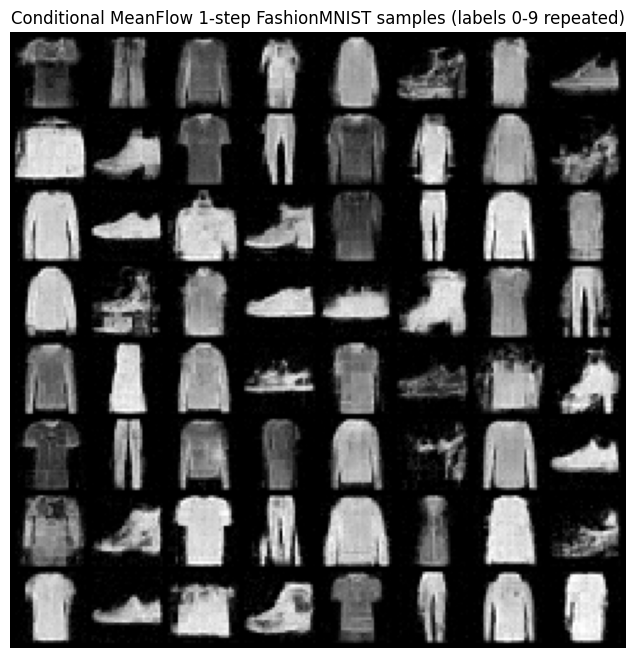

train: torch.Size([60000, 1, 28, 28])
test: torch.Size([10000, 1, 28, 28])


In [10]:
# One-step conditional MeanFlow sampler

def sample_meanflow_one_step(
    model,
    sample_count=64,
    seed=123,
    labels=None,
):
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(seed)
    z_1 = torch.randn(
        sample_count,
        1,
        28,
        28,
        generator=generator,
        device=DEVICE,
    )
    t = torch.ones(sample_count, device=DEVICE)
    r = torch.zeros(sample_count, device=DEVICE)
    if labels is None:
        labels = torch.arange(sample_count, device=DEVICE) % NUM_CLASSES
    average_velocity = model(
        z_1,
        r,
        t,
        labels,
    )
    return z_1 - average_velocity

# Generate and visualize a conditional preview batch
generated_preview = sample_meanflow_one_step(
    meanflow_ema,
    sample_count=64,
)
grid = make_grid(
    generated_preview[:64].cpu(),
    nrow=8,
    normalize=True,
    value_range=(-1, 1),
)
plt.figure(figsize=(8, 8))

plt.imshow(
    grid.permute(1, 2, 0).squeeze(),
    cmap="gray",
)
plt.axis("off")
plt.title("Conditional MeanFlow 1-step FashionMNIST samples " "(labels 0-9 repeated)")
plt.show()

# Materialize a DataLoader into CPU tensors for repeated analysis.
def materialize_loader(loader):
    image_batches = []
    label_batches = []
    for images, labels in loader:
        image_batches.append(images)
        label_batches.append(labels)
    return (torch.cat(image_batches, dim=0), torch.cat(label_batches, dim=0))

# Cache the complete train/test splits once.
train_images_all, train_labels_all = materialize_loader(
    DataLoader(
        dataset["train"],
        batch_size=512,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fashion_mnist,
    )
)

test_images_all, test_labels_all = materialize_loader(
    DataLoader(
        dataset["test"],
        batch_size=512,
        shuffle=False,
        num_workers=2,
        collate_fn=collate_fashion_mnist,
    )
)
print("train:", train_images_all.shape)
print("test:", test_images_all.shape)


# 1. Stanczuk et al. ICML 2024 — score-vector SVD로 intrinsic dimension 보기

**논문 질문.** 작은 noise에서 diffusion score가 data manifold의 normal bundle을 근사한다면,
한 데이터 주변에서 얻은 여러 score vector들의 span을 이용해 manifold의 intrinsic dimension을 읽을 수 있는가?

논문: *Diffusion Models Encode the Intrinsic Dimension of Data Manifolds*  
https://proceedings.mlr.press/v235/stanczuk24a.html

**원문 근거.** Abstract의 핵심 문장:

> “at low noise levels, the diffusion model provides us with an approximation of the manifold’s normal bundle”

프로젝트/논문의 estimator는 한 \(x_0\in\mathbb R^d\) 주변의 noisy points에서 score vector를 모아

\[
S=
\begin{bmatrix}
s_\theta(x_{t_0}^{(1)},t_0)&\cdots&s_\theta(x_{t_0}^{(d)},t_0)
\end{bmatrix}
\in\mathbb R^{d\times d}
\]

를 만들고 SVD한다. ordered singular values를 \(\sigma_1\ge\cdots\ge\sigma_d\)라 하면
가장 큰 gap 뒤까지를 normal dimension으로 보고

\[
\widehat{k}
=
d-
\operatorname*{arg\,max}_{i\in\{1,\dots,d-1\}}
(\sigma_i-\sigma_{i+1})
\]

로 intrinsic dimension을 추정한다.

**원 논문 Figure 5 / Table 1.** MNIST digit별 score spectrum을 그리고 각 digit의 estimated intrinsic dimension을 보고한다.
즉 이 실험은 MNIST 규모에서 원 논문이 직접 수행했다.

### 여기서 직접 유지하는 것
- low-noise corrupted points
- **raw score vectors 자체**를 \(S\)의 열로 쌓음
- \(S\)의 singular-value gap으로 ID 추정
- class별 분석

### adaptation
원 논문 score network 대신 MeanFlow diagonal velocity에서 정확한 path relation으로 만든
\(s_\theta(z,t)\)를 사용한다. MNIST 대신 FashionMNIST이므로 원 논문의 digit ID 수치와 일치할 이유는 없다.


In [11]:
# Experiment settings and class labels
FASHION_CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
AMBIENT_DIM = 28 * 28
STANCZUK_T0 = 0.05

SCORE_BATCH = 128

# Evaluate score vectors in memory-safe batches

def batched_score(model, images, t_value, batch_size=SCORE_BATCH):
    outputs = []
    for start in range(0, images.size(0), batch_size):
        end = min(start + batch_size, images.size(0))
        image_batch = images[start:end].to(DEVICE)
        t_batch = torch.full((image_batch.size(0),), float(t_value), device=DEVICE)
        score_batch = score_from_meanflow(model, image_batch, t_batch)
        outputs.append(score_batch.cpu())
    return torch.cat(outputs, dim=0)

# Pick one fixed anchor image for each class

def first_anchor_for_class(label):
    matching = torch.where(test_labels_all == label)[0]
    return test_images_all[matching[0]]

# Accumulate class-wise spectra and intrinsic-dimension estimates
stanczuk_rows = []
stanczuk_spectra = {}

# Measure the low-noise score spectrum for every class

for label in range(10):
    anchor = first_anchor_for_class(label)
    generator = torch.Generator()
    generator.manual_seed(SEED + label)
    noise = torch.randn(AMBIENT_DIM, 1, 28, 28, generator=generator)
    corrupted = (1.0 - STANCZUK_T0) * anchor[None] + STANCZUK_T0 * noise
    score_vectors = batched_score(meanflow_ema, corrupted, STANCZUK_T0)
    score_matrix = score_vectors.flatten(1).T.float()
    singular_values = torch.linalg.svdvals(score_matrix.to(DEVICE)).cpu()
    gaps = singular_values[:-1] - singular_values[1:]
    normal_dimension = int(torch.argmax(gaps).item() + 1)
    intrinsic_dimension = AMBIENT_DIM - normal_dimension
    stanczuk_spectra[label] = singular_values.numpy()
    stanczuk_rows.append(
        {
            "class": FASHION_CLASS_NAMES[label],
            "normal_dim": normal_dimension,
            "estimated_intrinsic_dim": intrinsic_dimension,
            "largest_gap": float(gaps.max()),
        }
    )


,class,normal_dim,estimated_intrinsic_dim,largest_gap
0,T-shirt/top,1,783,6501.802246
1,Trouser,1,783,4247.724121
2,Pullover,1,783,6333.132324
3,Dress,1,783,4884.063965
4,Coat,1,783,6213.217773
5,Sandal,1,783,3689.204346
6,Shirt,1,783,6154.962891
7,Sneaker,1,783,4869.194824
8,Bag,1,783,6747.113281
9,Ankle boot,1,783,5074.441406


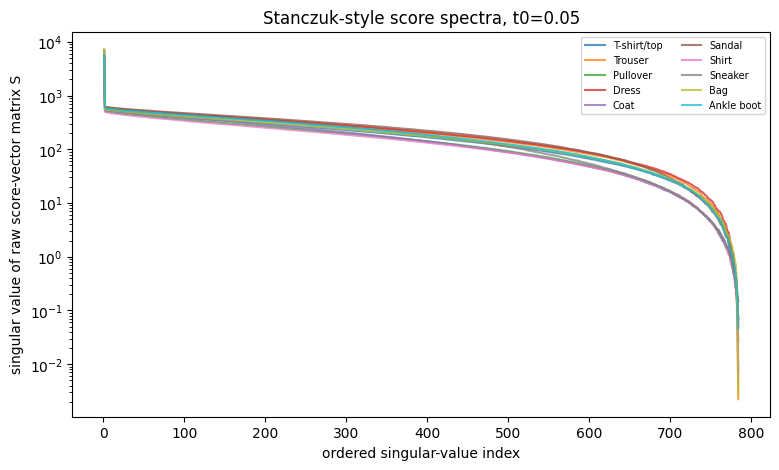

In [12]:
# Summarize the intrinsic-dimension estimates
stanczuk_table = pd.DataFrame(stanczuk_rows)
display(stanczuk_table)
plt.figure(figsize=(9, 5))

# Plot the class-wise singular-value spectra.
for label in range(10):
    spectrum = stanczuk_spectra[label]
    plt.plot(
        np.arange(1, len(spectrum) + 1),
        spectrum,
        label=FASHION_CLASS_NAMES[label],
        alpha=0.75,
    )

plt.yscale("log")
plt.xlabel("ordered singular-value index")
plt.ylabel("singular value of raw score-vector matrix S")
plt.title(f"Stanczuk-style score spectra, t0={STANCZUK_T0}")
plt.legend(fontsize=7, ncol=2)
plt.show()


# 2. Ventura et al. ICLR 2025 — score Jacobian spectrum과 geometric phases

**논문 질문.** score field의 local linearization이 manifold의 tangent/normal structure와 시간에 따른 subspace 분리를 보여주는가?

논문: *Manifolds, Random Matrices and Spectral Gaps: The geometric phases of generative diffusion*  
https://arxiv.org/abs/2410.05898

원 논문은 score Jacobian

\[
J_s(x,t)=D_xs_\theta(x,t):\mathbb R^d\to\mathbb R^d
\]

의 spectrum을 분석한다. Eq. (6)의 local linearization은

\[
s(x^\ast+p,t)\approx J_s(x^\ast,t)p
\]

이고, tangent direction은 작은 eigen/singular value,
normal direction은 큰 eigen/singular value와 연결된다.

**짧은 원문 인용.**

> “whose discontinuities (gaps) reveal the presence and dimensionality of distinct sub-manifolds.”

**Figure 5.** MNIST/CIFAR-10/CelebA에 대해 score-Jacobian spectra를 시간에 따라 측정한다.
논문은 이를 `trivial → manifold coverage → manifold consolidation`의 세 qualitative phase와 연결한다.

**Appendix C / Algorithm 2.** MNIST에서는 Gaussian perturbation을 orthogonalize하고,
central difference를 쓰는 symmetrized estimator가 더 안정적이라고 명시한다.
따라서 여기서도 \(d=784\)개의 orthogonal direction을 만들고

\[
S_i=
\frac{
s_\theta(x+\delta_i,t)-s_\theta(x-\delta_i,t)
}{2}
\]

를 열로 쌓은 뒤 SVD한다. 모든 perturbation의 크기가 같으므로 normalized spectrum을 볼 때
공통 scale factor는 gap 위치를 바꾸지 않는다.

### Stanczuk 실험과 다른 점
- Stanczuk: **raw nearby score vectors**의 span → low-noise ID estimator
- Ventura: **score의 directional change**, 즉 Jacobian action → 여러 \(t\)에서 spectral gaps/phase

### adaptation
원 논문 noise schedule 대신 현재 path의 noise std가 \(t\)이므로 perturbation radius를 \(t\sqrt d\)로 둔다.
우리는 한 FashionMNIST anchor에서 phase-like spectrum 변화가 나타나는지만 본다.


In [13]:
# Experiment settings and orthogonal probe directions
VENTURA_TIMES = [0.05, 0.1, 0.2, 0.4, 0.7]
VENTURA_LABEL = 7
VENTURA_BATCH = 128
anchor = first_anchor_for_class(VENTURA_LABEL).flatten().float()
generator = torch.Generator()
generator.manual_seed(SEED + 1000)
gaussian_directions = torch.randn(AMBIENT_DIM, AMBIENT_DIM, generator=generator)
orthogonal_directions, _ = torch.linalg.qr(gaussian_directions)
orthogonal_directions = orthogonal_directions.T
ventura_spectra = {}
ventura_gap_rows = []

# Estimate score-Jacobian spectra across noise levels

for t_value in VENTURA_TIMES:
    base = (1.0 - t_value) * anchor
    radius = t_value * math.sqrt(AMBIENT_DIM)
    perturbations = radius * orthogonal_directions
    plus = (base[None] + perturbations).reshape(AMBIENT_DIM, 1, 28, 28)
    minus = (base[None] - perturbations).reshape(AMBIENT_DIM, 1, 28, 28)
    score_plus = batched_score(
        meanflow_ema, plus, t_value, batch_size=VENTURA_BATCH
    ).flatten(1)
    score_minus = batched_score(
        meanflow_ema, minus, t_value, batch_size=VENTURA_BATCH
    ).flatten(1)
    directional_changes = (score_plus - score_minus) / 2.0
    jacobian_action_matrix = directional_changes.T.float()
    singular_values = torch.linalg.svdvals(jacobian_action_matrix.to(DEVICE)).cpu()
    normalized = singular_values / (singular_values.max() + 1e-12)
    ventura_spectra[t_value] = normalized.numpy()
    gaps = normalized[:-1] - normalized[1:]
    top_gap_indices = torch.topk(gaps, k=3).indices.cpu().numpy() + 1
    ventura_gap_rows.append(
        {
            "t": t_value,
            "largest_gap_after_index": int(top_gap_indices[0]),
            "top3_gap_indices": top_gap_indices.tolist(),
            "largest_gap": float(gaps.max()),
        }
    )


,t,largest_gap_after_index,top3_gap_indices,largest_gap
0,0.05,537,"[537, 483, 494]",0.015760
1,0.10,526,"[526, 516, 633]",0.012824
2,0.20,740,"[740, 781, 737]",0.014840
3,0.40,783,"[783, 780, 778]",0.066450
4,0.70,782,"[782, 783, 779]",0.221692


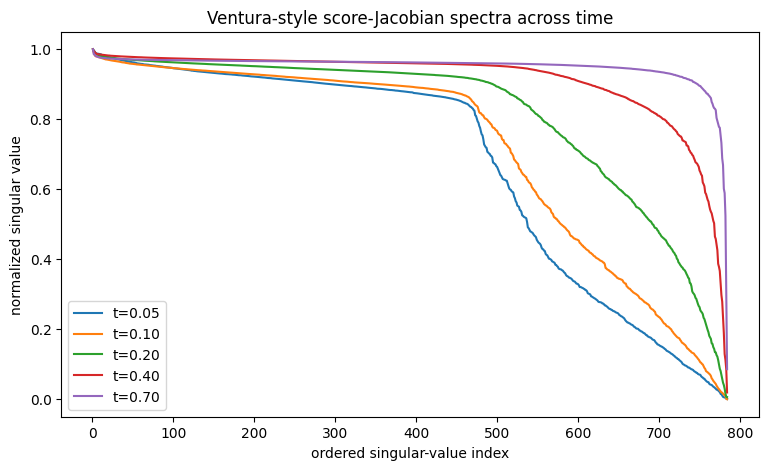

In [14]:
# Summarize spectral-gap locations
display(pd.DataFrame(ventura_gap_rows))
plt.figure(figsize=(9, 5))

# Plot normalized score-Jacobian spectra across time.
for t_value in VENTURA_TIMES:
    spectrum = ventura_spectra[t_value]
    plt.plot(np.arange(1, len(spectrum) + 1), spectrum, label=f"t={t_value:.2f}")

plt.xlabel("ordered singular-value index")
plt.ylabel("normalized singular value")
plt.title("Ventura-style score-Jacobian spectra across time")
plt.legend()
plt.show()


# 3. Niedoba et al. ICML 2025 — learned denoiser vs optimal empirical denoiser MSE

**논문 질문.** diffusion network가 empirical score-matching objective의 이론적 optimum을 그대로 학습하지 않는다면,
그 approximation error는 어느 noise 영역에서 커지며 어떤 inductive bias를 시사하는가?

논문: *Towards a Mechanistic Explanation of Diffusion Model Generalization*  
https://proceedings.mlr.press/v267/niedoba25a.html

**짧은 원문 인용.**

> “network denoisers generalize through localized denoising operations”

원 논문의 empirical optimal denoiser는 training empirical distribution에 대한 posterior mean이다.

\[
D_{\rm emp}(z,t)
=
\sum_{i=1}^{N}
p_t(x_i\mid z)\,x_i
\]

이고 Figure 2는 **network denoiser와 optimal empirical denoiser의 MSE**를 \(t\)에 따라 그린다.
논문은 150개 \(t\) 각각에 10,000 forward samples를 사용했고,
작은/큰 noise보다 중간 noise에서 approximation error가 커지는 패턴을 보고한다.

현재 linear path에서는

\[
p_t(z\mid x_i)
=
\mathcal N\big(z;(1-t)x_i,t^2I\big)
\]

이므로 full FashionMNIST training set으로 \(D_{\rm emp}\)를 정확히 계산할 수 있다.
MeanFlow의 network denoiser는

\[
D_\theta(z,t)=z-t\,u_\theta(z,t,t)
\]

이다.

### 직접 유지
- **같은 observable:** \( \|D_\theta-D_{\rm emp}\|_2^2 \)
- empirical posterior는 **전체 training set**을 사용
- forward-process samples에서 \(t\)-sweep

### adaptation
원 논문의 CIFAR-10 / EDM-style schedule 대신 FashionMNIST / \(z_t=(1-t)x+t\epsilon\)를 쓴다.
따라서 “어느 \(t\)에서 peak가 나와야 한다”는 원 논문 숫자를 강제하지 않는다.


In [15]:
ORACLE_TIMES = [0.03, 0.06, 0.1, 0.2, 0.4, 0.6, 0.8]
ORACLE_QUERY_COUNT = 16
train_bank_flat = train_images_all.flatten(1).to(DEVICE).float()
train_bank_norm2 = train_bank_flat.pow(2).sum(dim=1)

# Helper routines for empirical-denoiser comparison

def empirical_posterior_mean(z_t, t_value, bank_flat, bank_norm2):
    query = z_t.flatten(1).float()
    alpha = 1.0 - float(t_value)
    sigma2 = float(t_value) ** 2
    query_norm2 = query.pow(2).sum(dim=1, keepdim=True)
    cross = query @ bank_flat.T
    distances2 = query_norm2 + alpha**2 * bank_norm2[None] - 2.0 * alpha * cross
    logits = -distances2 / (2.0 * sigma2)
    weights = torch.softmax(logits, dim=1)
    posterior_mean = weights @ bank_flat
    return posterior_mean.reshape(z_t.size(0), 1, 28, 28)

oracle_rows = []
oracle_examples = {}
generator = torch.Generator(device=DEVICE)
generator.manual_seed(SEED + 2000)
query_indices = torch.randperm(
    len(train_images_all), generator=torch.Generator().manual_seed(SEED + 2000)
)[:ORACLE_QUERY_COUNT]
clean_queries = train_images_all[query_indices].to(DEVICE)

# Compare the learned denoiser with the empirical optimum across time

for t_value in ORACLE_TIMES:
    noise = torch.randn(clean_queries.shape, generator=generator, device=DEVICE)
    t_batch = torch.full((ORACLE_QUERY_COUNT,), t_value, device=DEVICE)
    z_t = linear_path(clean_queries, noise, t_batch)
    network_denoiser = denoiser_from_meanflow(meanflow_ema, z_t, t_batch)
    empirical_denoiser = empirical_posterior_mean(
        z_t, t_value, train_bank_flat, train_bank_norm2
    )
    per_sample_mse = (
        (network_denoiser - empirical_denoiser).pow(2).flatten(1).mean(dim=1)
    )
    oracle_rows.append(
        {
            "t": t_value,
            "mean_mse": float(per_sample_mse.mean()),
            "std_mse": float(per_sample_mse.std()),
        }
    )
    oracle_examples[t_value] = (
        z_t[0].cpu(),
        network_denoiser[0].cpu(),
        empirical_denoiser[0].cpu(),
    )


,t,mean_mse,std_mse
0,0.03,0.000779,0.000106
1,0.06,0.002231,0.000415
2,0.10,0.004393,0.001169
3,0.20,0.011444,0.004396
4,0.40,0.033381,0.015400
5,0.60,0.062609,0.037069
6,0.80,0.018987,0.013198


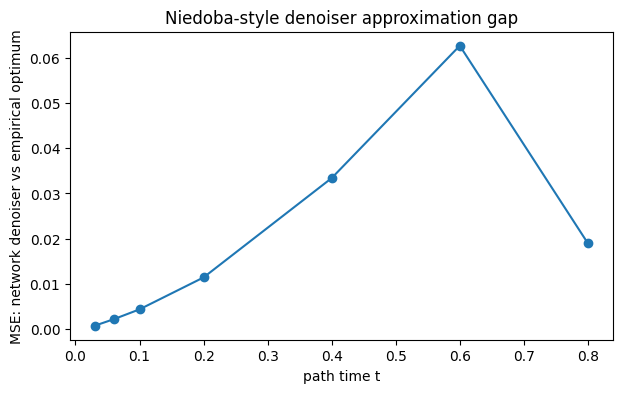

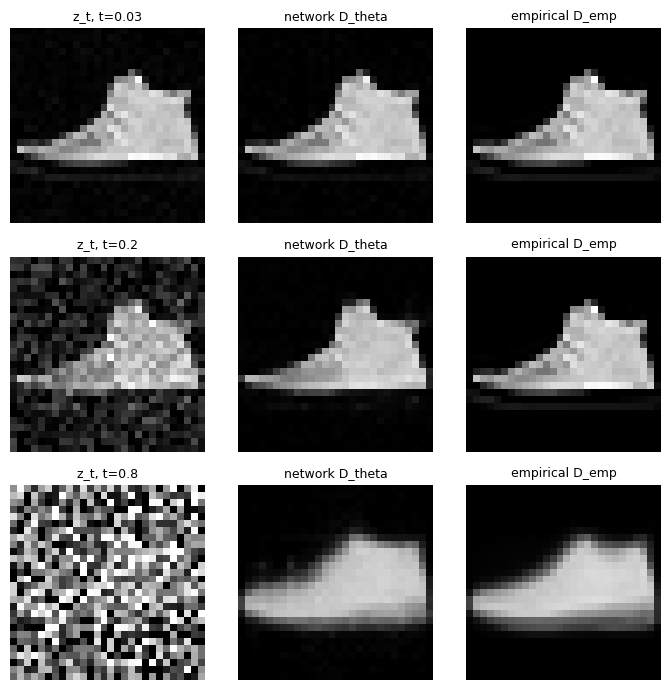

In [16]:
oracle_table = pd.DataFrame(oracle_rows)

# Summarize and visualize the denoiser error
display(oracle_table)
plt.figure(figsize=(7, 4))
plt.plot(oracle_table["t"], oracle_table["mean_mse"], marker="o")
plt.xlabel("path time t")
plt.ylabel("MSE: network denoiser vs empirical optimum")
plt.title("Niedoba-style denoiser approximation gap")
plt.show()
selected_times = [
    ORACLE_TIMES[0],
    ORACLE_TIMES[len(ORACLE_TIMES) // 2],
    ORACLE_TIMES[-1],
]
figure, axes = plt.subplots(len(selected_times), 3, figsize=(7, 7))

for row_index, t_value in enumerate(selected_times):
    noisy, network_out, empirical_out = oracle_examples[t_value]
    images = [noisy, network_out, empirical_out]
    titles = [f"z_t, t={t_value}", "network D_theta", "empirical D_emp"]
    for column_index, (image, title) in enumerate(zip(images, titles)):
        axes[row_index, column_index].imshow(
            image.squeeze(), cmap="gray", vmin=-1, vmax=1
        )
        axes[row_index, column_index].set_title(title, fontsize=9)
        axes[row_index, column_index].axis("off")

plt.tight_layout()
plt.show()


# 4. Li et al. NeurIPS 2025 — timestep별 representation linear probe

**논문 질문.** diffusion 내부 representation의 품질이 noise level에 따라 어떻게 변하며,
왜 중간 noise에서 가장 좋은 표현이 나타나는가?

논문: *Understanding Representation Dynamics of Diffusion Models via Low-Dimensional Modeling*  
https://proceedings.neurips.cc/paper_files/paper/2025/hash/9a3b1949b6da9b8facfdc28e1b4722ed-Abstract-Conference.html

**짧은 원문 인용.**

> “the quality of learned features peaks at an intermediate noise level.”

**Figure 1.** noisy input의 timestep을 바꾸어 downstream classification/segmentation 성능을 재고,
중간 noise에서 peak를 갖는 unimodal trend를 보여준다.

Appendix의 classification protocol은 각 noise level에서 input을 corrupt하고,
특정 decoder feature를 추출한 뒤 **logistic regression linear probe를 training split에서 학습하고 test split에서 평가**한다.
논문은 Figure 1(a)에서 여러 noise level 각각에 독립적인 probe를 사용한다.

### 직접 유지
\[
t\mapsto
\text{test accuracy of a linear/logistic probe on frozen features}
\]

### adaptation
원 논문은 U-Net decoder의 특정 `16x16 block1` feature를 사용한다.
우리 backbone은 DiT이므로 존재하지 않는 layer를 억지로 대응시키지 않고,
**각 DiT block 직후의 mean-pooled token feature를 모두 probe**한다.
관찰량은 동일하지만 feature location은 architecture adaptation이다.


In [17]:
PROBE_TIMES = [0.02, 0.05, 0.1, 0.2, 0.4, 0.6, 0.8]
PROBE_TRAIN_N = 6000
PROBE_TEST_N = 2000
PROBE_BATCH = 256

# Helper routines for representation extraction and low-dimensional analysis

def extract_features_at_time(model, images, t_value, batch_size=PROBE_BATCH):
    layer_feature_chunks = None
    for start in range(0, len(images), batch_size):
        end = min(start + batch_size, len(images))
        image_batch = images[start:end].to(DEVICE)
        t_batch = torch.full((image_batch.size(0),), float(t_value), device=DEVICE)
        noise = torch.randn_like(image_batch)
        z_t = linear_path(image_batch, noise, t_batch)
        features = model.forward_features(z_t, t_batch, t_batch)
        if layer_feature_chunks is None:
            layer_feature_chunks = [[] for _ in features]
        for layer_index, feature in enumerate(features):
            layer_feature_chunks[layer_index].append(feature.cpu())
    return [torch.cat(chunks, dim=0).numpy() for chunks in layer_feature_chunks]

probe_train_images = train_images_all[:PROBE_TRAIN_N]
probe_train_labels = train_labels_all[:PROBE_TRAIN_N].numpy()
probe_test_images = test_images_all[:PROBE_TEST_N]
probe_test_labels = test_labels_all[:PROBE_TEST_N].numpy()
probe_rows = []

# Track representation geometry across time

for t_value in PROBE_TIMES:
    torch.manual_seed(SEED + int(t_value * 10000))
    train_features = extract_features_at_time(meanflow_ema, probe_train_images, t_value)
    torch.manual_seed(SEED + 999 + int(t_value * 10000))
    test_features = extract_features_at_time(meanflow_ema, probe_test_images, t_value)
    for layer_index, (train_feature, test_feature) in enumerate(
        zip(train_features, test_features), start=1
    ):
        classifier = LogisticRegression(max_iter=400, solver="lbfgs")
        classifier.fit(train_feature, probe_train_labels)
        prediction = classifier.predict(test_feature)
        accuracy = accuracy_score(probe_test_labels, prediction)
        probe_rows.append({"t": t_value, "block": layer_index, "accuracy": accuracy})


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

,t,block,accuracy
0,0.02,1,0.6890
1,0.02,2,0.7600
2,0.02,3,0.7940
3,0.02,4,0.8030
4,0.05,1,0.6885
5,0.05,2,0.7565
6,0.05,3,0.7965
7,0.05,4,0.8065
8,0.10,1,0.6760
9,0.10,2,0.7515


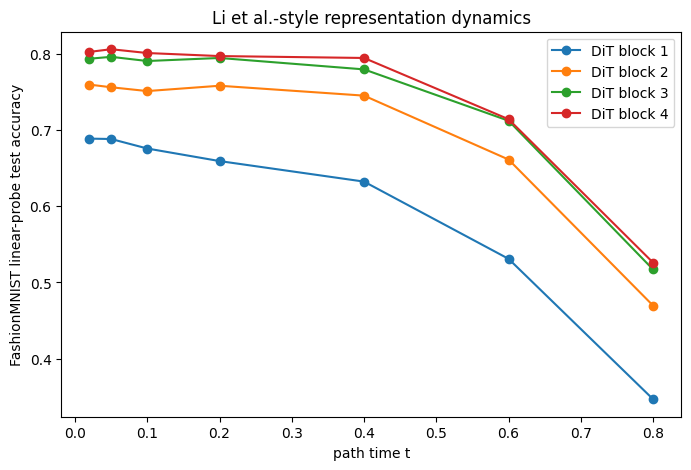

In [18]:
probe_table = pd.DataFrame(probe_rows)

# Summarize and visualize representation dynamics
display(probe_table)
plt.figure(figsize=(8, 5))

for block_index in sorted(probe_table["block"].unique()):
    subset = probe_table[probe_table["block"] == block_index]
    plt.plot(
        subset["t"], subset["accuracy"], marker="o", label=f"DiT block {block_index}"
    )

plt.xlabel("path time t")
plt.ylabel("FashionMNIST linear-probe test accuracy")
plt.title("Li et al.-style representation dynamics")
plt.legend()
plt.show()


# 5. Qian et al. CVPR 2024 — data-space estimate의 wavelet frequency evolution

**논문 질문.** denoising 과정에서 저주파 구조와 고주파 detail이 같은 속도로 복원되는가?

논문: *Boosting Diffusion Models with Moving Average Sampling in Frequency Domain (MASF)*  
https://openaccess.thecvf.com/content/CVPR2024/html/Qian_Boosting_Diffusion_Models_with_Moving_Average_Sampling_in_Frequency_Domain_CVPR_2024_paper.html

**짧은 원문 인용.**

> “diffusion models evolve the recovery from low-frequency components to high-frequency details”

논문 Figure 3의 MASF framework는 매 timestep의 noisy state를 먼저 **data space의 estimated clean sample**로 옮기고,
Haar DWT로

\[
x_t^{ll},\;
x_t^{lh},\;
x_t^{hl},\;
x_t^{hh}
\]

네 subband로 분해한다. \(ll\)은 low-frequency structure,
나머지 세 subband는 high-frequency detail로 해석한다.
Supplement Figure S.1은 estimated clean sample의 timestep evolution을 직접 추적한다.

### 직접 유지
- noisy/intermediate state가 아니라 **data-space clean estimate**를 분석
- Haar DWT의 \(LL,LH,HL,HH\) 네 subband
- timestep에 따른 frequency component evolution 관찰

MeanFlow에서는 data-space estimate를

\[
\widehat{x}_0^{(t)}
=
z_t-t\,u_\theta(z_t,t,t)
\]

로 둔다.

### adaptation
우리는 MASF moving-average sampler 자체를 적용하지 않는다.
**논문이 MASF의 동기로 사용한 frequency-evolution observation만 진단**한다.

아래의 `band RMS` curve는 네 subband의 변화를 숫자로 보기 위해 이 노트북에서 추가한 요약량이다.
따라서 이 scalar 자체를 “Qian et al.의 metric”이라고 해석하면 안 된다.


In [19]:
FREQUENCY_SAMPLE_COUNT = 32
FREQUENCY_STEPS = 12

# Frequency-domain helper routines

def meanflow_trajectory_with_clean_estimates(model, sample_count, steps, seed):
    generator = torch.Generator(device=DEVICE)
    generator.manual_seed(seed)
    z_t = torch.randn(sample_count, 1, 28, 28, generator=generator, device=DEVICE)
    times = torch.linspace(1.0, 0.0, steps + 1, device=DEVICE)
    clean_estimates = []
    recorded_times = []

    # Measure frequency-domain behavior over the chosen conditions
    for step_index in range(steps):
        t_value = float(times[step_index])
        r_value = float(times[step_index + 1])
        t_batch = torch.full((sample_count,), t_value, device=DEVICE)
        r_batch = torch.full((sample_count,), r_value, device=DEVICE)
        velocity = instantaneous_velocity(model, z_t, t_batch)
        clean_estimate = z_t - t_batch[:, None, None, None] * velocity
        clean_estimates.append(clean_estimate.cpu())
        recorded_times.append(t_value)
        interval_velocity = model(z_t, r_batch, t_batch)
        z_t = z_t - (t_value - r_value) * interval_velocity
    clean_estimates.append(z_t.cpu())
    recorded_times.append(0.0)
    return (recorded_times, clean_estimates)

frequency_times, clean_estimates = meanflow_trajectory_with_clean_estimates(
    meanflow_ema, FREQUENCY_SAMPLE_COUNT, FREQUENCY_STEPS, SEED + 3000
)

def haar_subbands(image_batch):
    band_lists = {"LL": [], "LH": [], "HL": [], "HH": []}
    for image in image_batch.numpy():
        array = image.squeeze()
        ll, (lh, hl, hh) = pywt.dwt2(array, "haar")
        band_lists["LL"].append(ll)
        band_lists["LH"].append(lh)
        band_lists["HL"].append(hl)
        band_lists["HH"].append(hh)
    return {name: np.stack(values, axis=0) for name, values in band_lists.items()}

frequency_rows = []
frequency_bands = []

for t_value, estimate_batch in zip(frequency_times, clean_estimates):
    bands = haar_subbands(estimate_batch)
    frequency_bands.append(bands)
    row = {"t": t_value}
    for band_name, coefficients in bands.items():
        row[f"{band_name}_rms"] = float(np.sqrt(np.mean(coefficients**2)))
    frequency_rows.append(row)


,t,LL_rms,LH_rms,HL_rms,HH_rms
0,1.000000,1.335352,0.144840,0.156650,0.058352
1,0.916667,1.396943,0.146591,0.174546,0.035289
2,0.833333,1.460558,0.166516,0.207940,0.033860
3,0.750000,1.513587,0.188914,0.241817,0.039413
4,0.666667,1.546697,0.208928,0.269671,0.047329
5,0.583333,1.566000,0.226211,0.290862,0.056496
6,0.500000,1.578054,0.241053,0.307976,0.066133
7,0.416667,1.586630,0.254728,0.323204,0.075843
8,0.333333,1.593208,0.267271,0.337488,0.085504
9,0.250000,1.598000,0.277769,0.350188,0.094909


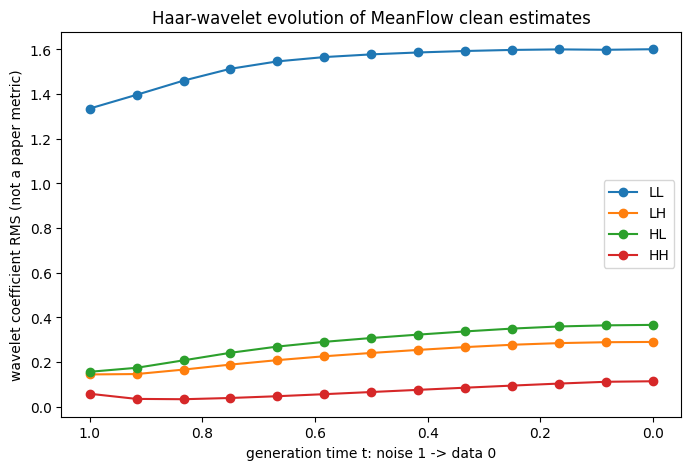

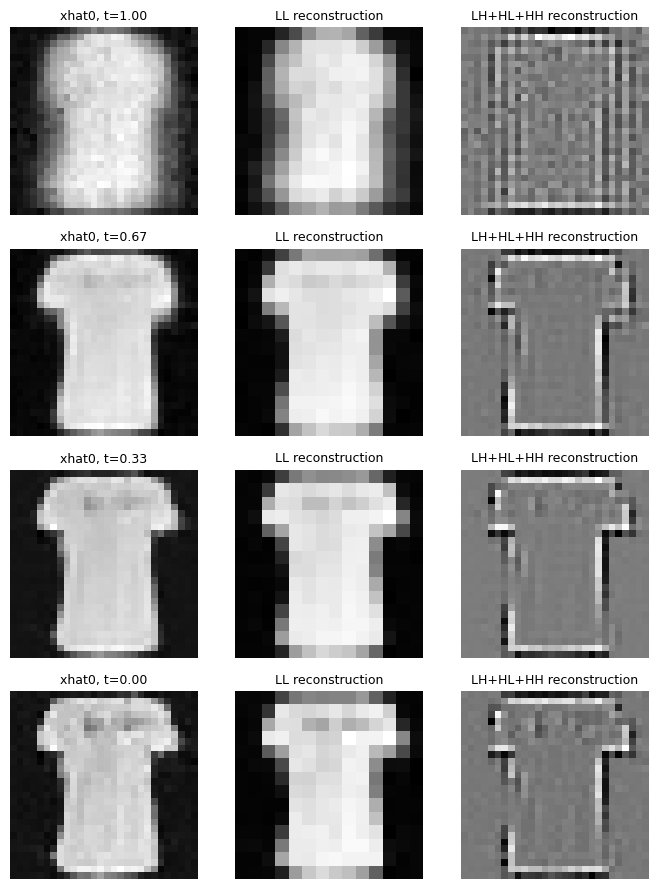

In [20]:
frequency_table = pd.DataFrame(frequency_rows)

# Summarize and visualize frequency-domain diagnostics
display(frequency_table)
plt.figure(figsize=(8, 5))

# Plot wavelet-band RMS across generation time.
for band_name in ["LL", "LH", "HL", "HH"]:
    plt.plot(
        frequency_table["t"],
        frequency_table[f"{band_name}_rms"],
        marker="o",
        label=band_name,
    )

plt.gca().invert_xaxis()
plt.xlabel("generation time t: noise 1 -> data 0")
plt.ylabel("wavelet coefficient RMS (not a paper metric)")
plt.title("Haar-wavelet evolution of MeanFlow clean estimates")
plt.legend()
plt.show()

# Reconstruct low- and high-frequency components for visual inspection.
def reconstruct_low_and_high(bands, sample_index):
    ll = bands["LL"][sample_index]
    lh = bands["LH"][sample_index]
    hl = bands["HL"][sample_index]
    hh = bands["HH"][sample_index]
    zeros_ll = np.zeros_like(ll)
    zeros_lh = np.zeros_like(lh)
    zeros_hl = np.zeros_like(hl)
    zeros_hh = np.zeros_like(hh)
    low = pywt.idwt2((ll, (zeros_lh, zeros_hl, zeros_hh)), "haar")
    high = pywt.idwt2((zeros_ll, (lh, hl, hh)), "haar")
    return (low, high)

selected_indices = [
    0,
    len(frequency_times) // 3,
    2 * len(frequency_times) // 3,
    len(frequency_times) - 1,
]
figure, axes = plt.subplots(len(selected_indices), 3, figsize=(7, 9))

for row_index, time_index in enumerate(selected_indices):
    full = clean_estimates[time_index][0].squeeze().numpy()
    low, high = reconstruct_low_and_high(frequency_bands[time_index], sample_index=0)
    panels = [full, low, high]
    titles = [
        f"xhat0, t={frequency_times[time_index]:.2f}",
        "LL reconstruction",
        "LH+HL+HH reconstruction",
    ]
    for column_index, (panel, title) in enumerate(zip(panels, titles)):
        axes[row_index, column_index].imshow(panel, cmap="gray")
        axes[row_index, column_index].set_title(title, fontsize=9)
        axes[row_index, column_index].axis("off")

plt.tight_layout()
plt.show()


# 6. Buchanan et al. NeurIPS 2025 — strict nearest-neighbor memorization criterion

**논문 질문.** 생성물이 training set의 단순 복사에 가까운 regime과 새로운 sample을 생성하는 regime을
어떻게 정량적으로 분리할 수 있는가?

논문: *On the Edge of Memorization in Diffusion Models*  
https://papers.nips.cc/paper_files/paper/2025/hash/8a6a3f289e3e2654509ccfdd631e592e-Abstract-Conference.html

논문 Definition 2.2는 training set

\[
\mathcal D=\{x_i\}_{i=1}^{N}\subset\mathbb R^d
\]

에 대해 generated sample \(\hat x\)의 첫 번째와 두 번째 \(L_2\) nearest neighbors를
\(x_{(1)},x_{(2)}\)라 하고,

\[
\|\hat x-x_{(1)}\|_2
\le
c\,
\|\hat x-x_{(2)}\|_2
\]

이면 memorized sample로 정의한다.

**짧은 원문 인용.**

> “We adopt a popular, relatively strict metric for memorization”

논문의 numerical experiments에서는 \(c=1/9\)를 사용한다.

### 직접 유지
- pixel-space Euclidean \(L_2\)
- 1-NN과 2-NN distance의 ratio
- criterion \(c=1/9\)
- memorized-sample ratio

### adaptation
논문은 model-size/data-complexity sweep으로 phase transition을 연구한다.
여기서는 **현재 MeanFlow checkpoint 하나가 얼마나 training sample 복사에 가까운지**만 진단한다.
따라서 phase-transition 재현은 아니다.


In [21]:
MEMORIZATION_SAMPLE_COUNT = 128
MEMORIZATION_C = 1.0 / 9.0

# Helper routines for nearest-neighbor and memorization diagnostics

def nearest_two_l2_distances(generated, training_bank):
    generated_flat = generated.flatten(1).float()
    training_flat = training_bank.flatten(1).float()
    generated_norm2 = generated_flat.pow(2).sum(dim=1, keepdim=True)
    training_norm2 = training_flat.pow(2).sum(dim=1)
    distances2 = (
        generated_norm2
        + training_norm2[None]
        - 2.0 * (generated_flat @ training_flat.T)
    )
    distances2 = distances2.clamp_min(0.0)
    top2_values, top2_indices = torch.topk(distances2, k=2, largest=False, dim=1)
    top2_distances = torch.sqrt(top2_values + 1e-12)
    return (top2_distances, top2_indices)


memorization ratio at c=1/9: 0.0
minimum d1/d2: 0.8042377233505249
median d1/d2: 0.9747635126113892


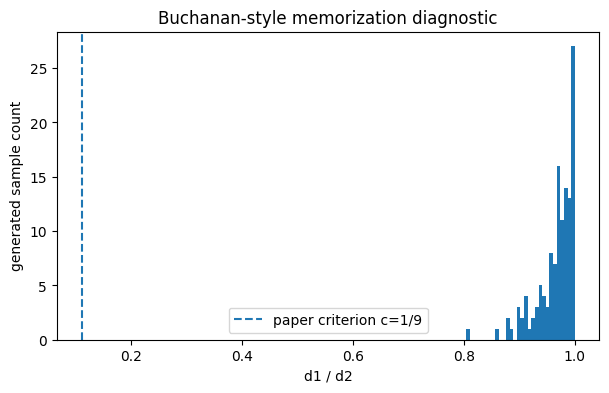

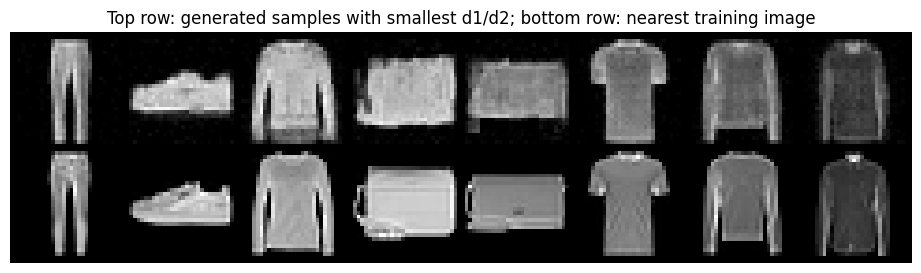

In [22]:
# Compute nearest-neighbor distance ratios and the strict memorization mask.
generated_for_memorization = sample_meanflow_one_step(
    meanflow_ema, sample_count=MEMORIZATION_SAMPLE_COUNT, seed=SEED + 4000
)
training_bank_gpu = train_images_all.to(DEVICE)
nearest_distances, nearest_indices = nearest_two_l2_distances(
    generated_for_memorization, training_bank_gpu
)
distance_ratio = nearest_distances[:, 0] / nearest_distances[:, 1]
memorized_mask = distance_ratio <= MEMORIZATION_C
memorization_ratio = float(memorized_mask.float().mean())
print("memorization ratio at c=1/9:", memorization_ratio)
print("minimum d1/d2:", float(distance_ratio.min()))
print("median d1/d2:", float(distance_ratio.median()))

# Results and visualization
plt.figure(figsize=(7, 4))

plt.hist(distance_ratio.cpu().numpy(), bins=30)
plt.axvline(MEMORIZATION_C, linestyle="--", label="paper criterion c=1/9")
plt.xlabel("d1 / d2")
plt.ylabel("generated sample count")
plt.title("Buchanan-style memorization diagnostic")
plt.legend()
plt.show()
# Inspect generated samples with the smallest d1/d2 ratios.
most_suspicious = torch.argsort(distance_ratio)[:8]
generated_show = generated_for_memorization[most_suspicious].cpu()
nearest_training_show = train_images_all[nearest_indices[most_suspicious, 0].cpu()]
comparison = torch.cat([generated_show, nearest_training_show], dim=0)
grid = make_grid(comparison, nrow=8, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(12, 3))
plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray")

plt.axis("off")
plt.title(
    "Top row: generated samples with smallest d1/d2; bottom row: nearest training image"
)
plt.show()


# 7. AlphaFlow ICLR 2026 — MeanFlow loss decomposition의 gradient conflict

**논문 질문.** MeanFlow objective가 왜 최적화하기 어려울 수 있는가?
한 scalar loss 안에 서로 반대 방향의 parameter update를 요구하는 두 성분이 숨어 있는가?

논문: *AlphaFlow: Understanding and Improving MeanFlow Models*  
https://arxiv.org/abs/2510.20771

AlphaFlow Eq. (6)은 MeanFlow loss를 parameter-independent constant \(C\)를 제외하고

\[
\mathcal L_{\rm MF}
=
\mathcal L_{\rm TFM}
+
\mathcal L_{\rm TC_c}
+
C
\]

로 분해한다.

\[
\mathcal L_{\rm TFM}
=
\mathbb E
\|u_\theta(z_t,r,t)-v_t\|_2^2
\]

\[
\mathcal L_{\rm TC_c}
=
\mathbb E
\left[
2(t-r)
u_\theta(z_t,r,t)^\top
\frac{d u_{\theta^-}(z_t,r,t)}{dt}
\right]
\]

이다. \(\theta^-\)는 derivative term 쪽 parameter-gradient를 stop하는 의미다.

두 loss의 parameter gradient

\[
g_a=\nabla_\theta \mathcal L_a,\qquad
g_b=\nabla_\theta \mathcal L_b
\]

에 대해

\[
\operatorname{cos}(g_a,g_b)
=
\frac{\langle g_a,g_b\rangle}
{\|g_a\|_2\|g_b\|_2}
\]

를 측정한다.

**짧은 원문 인용.**

> “these two gradients are strongly negatively correlated, with a similarity typically below -0.4.”

**Figure 2(a).** training throughout에서
\(\nabla L_{\rm TC_c}\) vs \(\nabla L_{\rm TFM}\),
그리고 border flow-matching loss \(L_{\rm FM'}\) vs \(L_{\rm TC_c}\)의 cosine을 비교한다.
Appendix는 같은 batch에서 세 gradient를 계산하고 이 과정을 1000 iteration 반복해 mean과 5/95 percentile을 얻는다고 명시한다.

### 직접 유지
- Eq. (6)의 **동일한 두 loss component**
- derivative branch에 stop-gradient
- parameter-gradient cosine similarity
- TFM–TC와 FM'–TC를 같은 batch에서 비교
- training snapshot에 따라 추적

### adaptation
원 논문은 ImageNet DiT에서 1000 batches/checkpoint를 사용한다.
여기서는 T4 시간을 줄이기 위해 snapshot마다 소수 batch만 사용한다.
따라서 \(-0.4\)를 목표값으로 맞추지 않는다. **부호와 상대적 conflict가 재현되는지**를 본다.


In [23]:
# AlphaFlow diagnostic settings
ALPHAFLOW_BATCHES_PER_SNAPSHOT = 6

def flatten_parameter_gradients(gradients, parameters):
    flattened = []
    for gradient, parameter in zip(gradients, parameters):
        if gradient is None:
            flattened.append(torch.zeros_like(parameter).flatten())
        else:
            flattened.append(gradient.flatten())
    return torch.cat(flattened)

def gradient_cosine(first_gradient, second_gradient):
    denominator = (first_gradient.norm() * second_gradient.norm()).clamp_min(1e-12)
    return float(torch.dot(first_gradient, second_gradient) / denominator)

# Compute the two AlphaFlow gradient-cosine diagnostics on one batch

def alphaflow_cosines_on_batch(model, clean_images):
    # Build one MeanFlow batch and its JVP derivative.
    model.zero_grad(set_to_none=True)
    batch_size = clean_images.size(0)
    r, t = sample_meanflow_times(batch_size, clean_images.device)
    noise = torch.randn_like(clean_images)
    z_t = linear_path(clean_images, noise, t)
    velocity = conditional_velocity(clean_images, noise)
    zero = torch.zeros_like(t)
    one = torch.ones_like(t)
    average_velocity, total_derivative = meanflow_jvp(
        lambda z_arg, r_arg, t_arg: model(z_arg, r_arg, t_arg),
        (z_t, r, t),
        (velocity, zero, one),
    )
    # Decompose the AlphaFlow objective into TFM, TCc, and border-FM terms.
    derivative_stopped = total_derivative.detach()
    tfm_per_sample = (average_velocity - velocity).pow(2).flatten(1).sum(dim=1)
    loss_tfm = tfm_per_sample.mean()
    inner_product = (average_velocity * derivative_stopped).flatten(1).sum(dim=1)
    loss_tc = (2.0 * (t - r) * inner_product).mean()
    border_velocity = model(z_t, t, t)
    fm_prime_per_sample = (border_velocity - velocity).pow(2).flatten(1).sum(dim=1)
    loss_fm_prime = fm_prime_per_sample.mean()
    # Differentiate each component with respect to the same parameter set.
    parameters = [
        parameter for parameter in model.parameters() if parameter.requires_grad
    ]
    gradients_tfm = torch.autograd.grad(
        loss_tfm, parameters, retain_graph=True, allow_unused=True
    )
    gradients_tc = torch.autograd.grad(
        loss_tc, parameters, retain_graph=True, allow_unused=True
    )
    gradients_fm_prime = torch.autograd.grad(
        loss_fm_prime, parameters, allow_unused=True
    )
    # Flatten parameter gradients before computing cosine similarity.
    flat_tfm = flatten_parameter_gradients(gradients_tfm, parameters)
    flat_tc = flatten_parameter_gradients(gradients_tc, parameters)
    flat_fm_prime = flatten_parameter_gradients(gradients_fm_prime, parameters)
    return {
        "tfm_vs_tc": gradient_cosine(flat_tfm, flat_tc),
        "fm_prime_vs_tc": gradient_cosine(flat_fm_prime, flat_tc),
    }

# Recover the training step encoded in each snapshot filename

def snapshot_step_from_path(path):
    stem = os.path.basename(path)
    number = stem.replace("meanflow_step_", "").replace(".pt", "")
    return int(number)

available_snapshot_paths = sorted(
    [
        os.path.join(CHECKPOINT_DIR, filename)
        for filename in os.listdir(CHECKPOINT_DIR)
        if filename.startswith("meanflow_step_") and filename.endswith(".pt")
    ],
    key=snapshot_step_from_path,
)

if len(available_snapshot_paths) == 0:
    warnings.warn(
        "No training snapshots found. AlphaFlow analysis will use only the final EMA weights."
    )
    final_fallback = os.path.join(CHECKPOINT_DIR, "meanflow_ema.pt")
    available_snapshot_paths = [final_fallback]

# Reuse the training distribution for snapshot diagnostics
analysis_loader_iterator = infinite_batches(train_loader)
alphaflow_rows = []

# Evaluate every available training snapshot

for snapshot_path in available_snapshot_paths:

    # Restore one snapshot into a fresh analysis model
    analysis_model = fresh_model()
    analysis_model.load_state_dict(torch.load(snapshot_path, map_location=DEVICE))
    analysis_model.train()
    if "meanflow_step_" in snapshot_path:
        step_value = snapshot_step_from_path(snapshot_path)
    else:
        step_value = TRAIN_STEPS

    # Collect per-batch cosine values before aggregating statistics
    tfm_tc_values = []
    fm_tc_values = []

    # Average diagnostics over several independent mini-batches
    for _ in range(ALPHAFLOW_BATCHES_PER_SNAPSHOT):
        clean_images, _ = next(analysis_loader_iterator)
        clean_images = clean_images.to(DEVICE, non_blocking=True)
        result = alphaflow_cosines_on_batch(analysis_model, clean_images)
        tfm_tc_values.append(result["tfm_vs_tc"])
        fm_tc_values.append(result["fm_prime_vs_tc"])

    # Record mean and tail percentiles for each cosine pair
    for pair_name, values in [
        ("TFM vs TCc", tfm_tc_values),
        ("FM' vs TCc", fm_tc_values),
    ]:
        values_array = np.asarray(values)
        alphaflow_rows.append(
            {
                "step": step_value,
                "pair": pair_name,
                "mean": float(values_array.mean()),
                "p05": float(np.percentile(values_array, 5)),
                "p95": float(np.percentile(values_array, 95)),
            }
        )

    # Release the snapshot model before loading the next checkpoint
    del analysis_model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()


,step,pair,mean,p05,p95
0,1000,TFM vs TCc,0.251594,0.097303,0.380574
1,1000,FM' vs TCc,0.221015,0.075197,0.370121
2,2000,TFM vs TCc,0.143611,-0.114424,0.356355
3,2000,FM' vs TCc,0.189608,-0.038342,0.383670
4,3000,TFM vs TCc,0.331004,0.024986,0.582492
5,3000,FM' vs TCc,0.342250,0.071838,0.587620
6,4000,TFM vs TCc,0.133498,-0.043193,0.336939
7,4000,FM' vs TCc,0.169758,0.022033,0.339936
8,5000,TFM vs TCc,0.203903,0.005642,0.455805
9,5000,FM' vs TCc,0.136462,-0.015011,0.407459


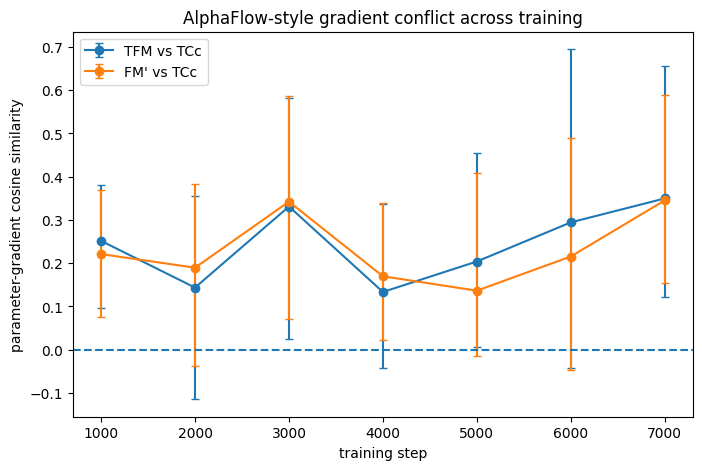

In [24]:
# Summarize snapshot-wise AlphaFlow diagnostics
alphaflow_table = pd.DataFrame(alphaflow_rows)
display(alphaflow_table)
plt.figure(figsize=(8, 5))

for pair_name in alphaflow_table["pair"].unique():
    subset = alphaflow_table[alphaflow_table["pair"] == pair_name].sort_values("step")
    lower_error = subset["mean"] - subset["p05"]
    upper_error = subset["p95"] - subset["mean"]
    plt.errorbar(
        subset["step"],
        subset["mean"],
        yerr=np.vstack([lower_error, upper_error]),
        marker="o",
        capsize=3,
        label=pair_name,
    )

plt.axhline(0.0, linestyle="--")
plt.xlabel("training step")
plt.ylabel("parameter-gradient cosine similarity")
plt.title("AlphaFlow-style gradient conflict across training")
plt.legend()
plt.show()


# 8. 결과를 읽는 순서

이 노트북에서 중요한 것은 “좋은 숫자” 하나가 아니라 **서로 다른 논문이 같은 MeanFlow를 어떤 관점으로 해부하는가**다.

1. **Stanczuk**  
   low-noise score vector들이 몇 차원의 normal subspace를 실질적으로 span하는가?
2. **Ventura**  
   score의 미분 \(D_xs_\theta\) 자체는 시간에 따라 어떤 spectral subspace/gap을 만드는가?
3. **Niedoba**  
   network가 empirical objective의 exact optimum과 어디서 갈라지는가?
4. **Li**  
   같은 network의 hidden representation은 어느 noise scale에서 class information을 가장 잘 선형 분리하는가?
5. **Qian**  
   data-space clean estimate에서 low/high-frequency component는 generation time에 따라 어떻게 나타나는가?
6. **Buchanan**  
   최종 sample이 training set의 한 점에 비정상적으로 가까운 strict memorization을 보이는가?
7. **AlphaFlow**  
   MeanFlow training objective 내부의 두 수학적 성분이 parameter space에서 서로 협력하는가, 충돌하는가?

서로 다른 결과가 모순처럼 보여도 바로 결론내리지 않는다.
예를 들어 representation probe가 좋아지는 \(t\)와 Jacobian gap이 커지는 \(t\)가 같아야 한다는 주장은 어느 원 논문에도 없다.
각 진단이 정의한 수학량과 질문을 먼저 유지한 뒤, **상관이 실제 결과에서 나타날 때만** 추가 가설을 세운다.


# 변경 이력

## 2026-09-09 — MeanFlow 학습의 JVP 계산량 축소

### 변경 이유

`mean_flow_experiment1.ipynb`를 코랩 T4에서 학습할 때, PyTorch가 선택한 `_scaled_dot_product_efficient_attention` 커널이 정방향 자동 미분(JVP)을 지원하지 않아 중단됐다. `MultiheadAttention`의 빠른 경로를 끄는 설정만으로는 내부 SDPA 커널 선택까지 제한할 수 없었다.

처음에는 모든 attention 호출에 `SDPBackend.MATH`를 지정해 오류를 해결했다. 이후 학습 배치 전체에 필요하지 않은 JVP까지 계산하는 부분을 줄이고, 기본 수학 연산 방식의 적용 범위를 JVP 구간으로 좁혔다.

### 변경 내용

- `meanflow_outputs`에서 시간·노이즈·조건 레이블 드롭아웃을 한 번 샘플링한 뒤, `r=t`와 `r≠t` 샘플을 나눈다.
- `r=t` 샘플은 일반 순전파로 예측하고, 회귀 타깃은 `v`를 사용한다. 이 샘플도 기존처럼 손실과 파라미터 역전파에 참여한다.
- `r≠t` 샘플에만 JVP를 계산해 타깃 `v − (t−r)·JVP`를 구성한다. 예측값은 JVP 호출에서 함께 얻으므로 별도 순전파를 반복하지 않는다.
- 두 결과를 원래 샘플 순서로 복원한 뒤 기존 배치 전체의 적응형 손실을 계산한다. 타깃의 stop-gradient, 조건 레이블, 시간 분포와 학습 배치 크기를 유지한다.
- `meanflow_jvp`가 JVP 실행 중에만 `MATH` attention을 선택한다. 일반 순전파와 생성은 PyTorch의 기본 SDPA 선택을 사용한다. 경계 검증과 AlphaFlow 분석의 직접 JVP 호출도 이 함수를 사용한다.

현재 `BATCH_SIZE=128`, `DATA_PROPORTION=0.75`에서는 96개가 일반 순전파, 32개가 JVP 경로를 사용한다. 일반적으로 대각 샘플 수는 `int(batch_size * DATA_PROPORTION)`이며, 우연히 시간이 같은 추가 샘플도 JVP에서 제외된다. 경계 검증과 AlphaFlow 분석은 기존 분석 계산 범위를 유지한다.

### 수학적 근거와 적용 조건

MeanFlow 타깃은 `v − (t−r)·JVP`다. `r=t`일 때 JVP의 계수가 0이므로 해당 미분을 생략할 수 있다. 현재 TinyDiT는 배치 샘플끼리 연산을 섞지 않고 attention dropout도 0이므로 배치를 분리해도 수학적으로 같은 예측·타깃·손실·파라미터 기울기를 얻는다. 부동소수점 연산 순서와 SDPA backend 차이로 작은 수치 오차는 발생할 수 있다. 향후 BatchNorm이나 확률적 모델 층을 추가하면 동등성을 다시 확인해야 한다.

### 가속 커널 대안과 T4 제약

MeanFlow는 [2025년 5월 19일 공개](https://arxiv.org/abs/2505.13447)됐으며, JVP를 지원하는 가속 attention 구현도 존재한다.

| 대안 | 적용 시 확인할 사항 |
| --- | --- |
| [NVIDIA RCM의 FlashAttention JVP](https://github.com/NVlabs/rcm/blob/main/rcm/utils/flash_attention_jvp_triton.py) | Triton 기반 JVP 구현이다. 사용 GPU, 입력 크기, 정밀도와 역전파 호환성을 검증한 뒤 통합해야 한다. |
| [jvp_flash_attention](https://github.com/amorehead/jvp_flash_attention) | `torch.func.jvp` 사용 시 `JVPAttn.fwd_dual` 경로가 안내돼 있다. 확인한 구현은 헤드 차원에 16·32·64·128·256을 요구하고 시퀀스 길이에도 제약이 있어, 현재 모델의 49개 토큰·헤드 차원 28을 그대로 넣을 수 없다. 패딩을 적용한다면 마스킹과 attention 스케일을 보존해야 한다. |
| [Decoupled MeanFlow의 FA2·FA3 JVP 경로](https://github.com/kyungmnlee/dmf) | 프로젝트에서 JVP 지원 attention 경로를 제공한다. 안내 환경은 FA2용 Ampere, FA3용 Hopper 계열이다. |

[일반 FlashAttention-2 CUDA 구현](https://github.com/Dao-AILab/flash-attention#nvidia-cuda-support)은 Ampere·Ada·Hopper를 지원 대상으로 안내한다. T4는 Turing 세대이므로 별도 [flash-attention-turing](https://github.com/ssiu/flash-attention-turing) 구현을 확인해야 하며, Turing 지원 자체가 MeanFlow에 필요한 JVP 지원을 보장하지는 않는다. 위 대안들이 모두 T4에서 불가능하다는 의미는 아니지만, 이번 변경에서는 T4에서 검증하지 못한 외부 커널을 추가하지 않았다.

### 검증과 성능 한계

검증 코드는 `tests/test_mean_flow_experiment1.py`에 있다. 전체 배치에 JVP를 적용하는 기준 구현과 분리 구현을 같은 난수·모델 파라미터로 비교하고, 대각 샘플만 있는 경우·구간 샘플만 있는 경우·혼합 배치 및 조건 레이블 없는 입력을 확인한다. CUDA가 있으면 FP16 혼합 정밀도 학습 검사도 실행한다.

로컬 CPU 검증은 4개 테스트가 통과했고 CUDA 테스트 1개는 GPU 부재로 건너뛰었다. 예측값·타깃·손실·전체 파라미터 기울기와 난수 상태의 동등성, JVP 호출 배치 크기, backend 설정 복원, 미분값의 유한차분 비교 및 학습 업데이트를 확인했다.

JVP 대상 샘플 수가 기본 설정에서 128개에서 32개로 감소한다. 전체 학습의 4배 가속을 뜻하지는 않는다. 일반 순전파·역전파는 여전히 모든 샘플에 필요하고, 배치 분할·인덱싱·GPU 동기화 비용도 추가된다. 특히 토큰 수가 49개로 짧아 전용 attention 커널의 큰 시퀀스 벤치마크 배율을 그대로 적용할 수 없다. 로컬 환경은 CPU 전용이므로 T4의 실제 처리 시간·최대 GPU 메모리와 가속 배율은 미측정이다.
